## Extended Data Fig. 7c

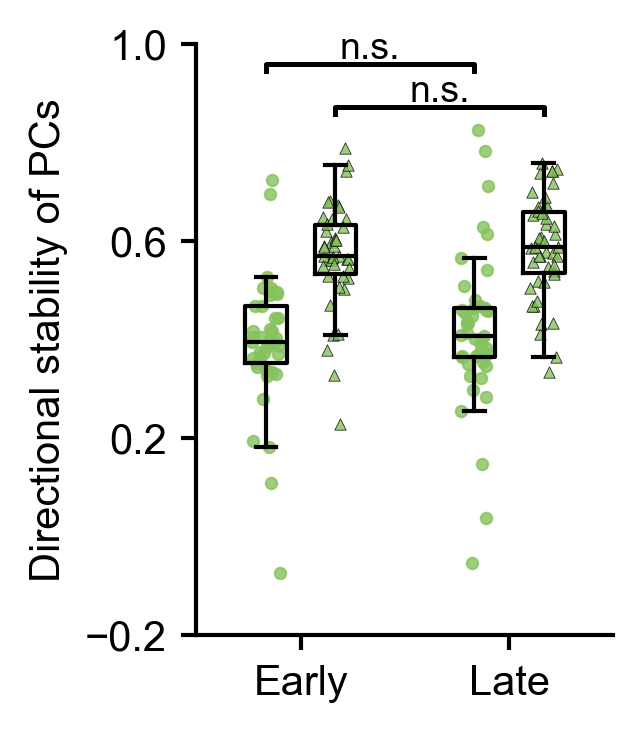

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../Results4Plots/directional stability_PCs.csv").copy()
df = df.copy()
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

df = df[
    (df["Stage"].isin(["early", "late"]))
    & (df["Env"].isin(["R", "VR"]))
    & (df["Value"].notna())
].copy()

colorPC = np.array([134, 194, 93]) / 255.0

xpos = {
    ("early", "VR"): 1,
    ("early", "R"): 2,
    ("late", "VR"): 4,
    ("late", "R"): 5
}

rng = np.random.default_rng(0)
jitter_width = 0.4

fig, ax = plt.subplots(figsize=(2, 2.3), dpi=300)

for stage in ["early", "late"]:
    for env in ["VR", "R"]:
        y = df.loc[
            (df["Stage"] == stage) & (df["Env"] == env),
            "Value"
        ].to_numpy(dtype=float)

        y = y[np.isfinite(y)]

        if y.size == 0:
            continue

        x0 = xpos[(stage, env)]
        jitter = (rng.random(y.size) - 0.5) * jitter_width

        if env == "VR":
            ax.scatter(
                x0 + jitter,
                y,
                s=7.5,
                marker="o",
                facecolors=colorPC,
                edgecolors=colorPC,
                linewidths=0.5,
                alpha=0.8,
                zorder=1
            )
        else:
            ax.scatter(
                x0 + jitter,
                y,
                s=7.5,
                marker="^",
                facecolors=colorPC,
                edgecolors="k",
                linewidths=0.2,
                alpha=0.8,
                zorder=1
            )

        ax.boxplot(
            y,
            positions=[x0],
            widths=0.6,
            showfliers=False,
            patch_artist=False,
            boxprops=dict(color="k", linewidth=1),
            medianprops=dict(color="k", linewidth=1),
            whiskerprops=dict(color="k", linewidth=1),
            capprops=dict(color="k", linewidth=1)
        )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for label in ax.get_yticklabels():
    label.set_fontname("Arial")

ax.set_ylabel("Directional stability of PCs", fontsize=10, fontname="Arial")
ax.set_xticks([1.5, 4.5])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)

ymin, ymax = ax.get_ylim()
yr = ymax - ymin
h = 0.015 * yr
gap = 0.02 * yr
text_offset = 0.009 * yr

vr_values = df.loc[df["Env"] == "VR", "Value"].to_numpy(dtype=float)
r_values = df.loc[df["Env"] == "R", "Value"].to_numpy(dtype=float)

vr_values = vr_values[np.isfinite(vr_values)]
r_values = r_values[np.isfinite(r_values)]

y_vr = np.nanmax(vr_values) + gap + 0.1
y_r = np.nanmax(r_values) + gap + 0.12 * yr - 0.07

ax.plot([1, 1, 4, 4], [y_vr, y_vr + h, y_vr + h, y_vr], lw=1.2, c="k")
ax.text(2.5, y_vr + h + text_offset - 0.01, "n.s.", ha="center", va="bottom", fontname="Arial", fontsize=9)

ax.plot([2, 2, 5, 5], [y_r, y_r + h, y_r + h, y_r], lw=1.2, c="k")
ax.text(3.5, y_r + h + text_offset - 0.01, "n.s.", ha="center", va="bottom", fontname="Arial", fontsize=9)

ax.set_ylim(-0.2, 1)
ax.set_yticks([-0.2, 0.2, 0.6, 1])
ax.set_xlim(0, 6)

plt.tight_layout(pad=0.2)
plt.show()

## Extended Data Fig. 7d

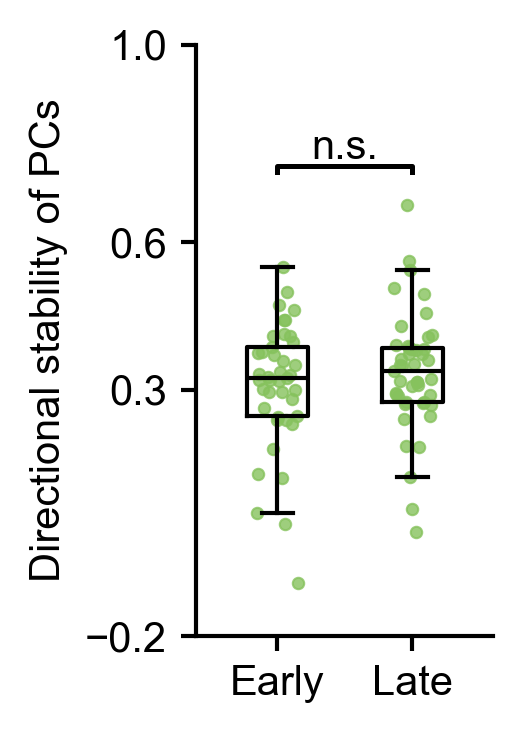

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("../Results4Plots/directional stability_PCs_matched.csv").copy()
df = df.copy()
df["Value"] = pd.to_numeric(df["Value"], errors="coerce")

df = df[
    (df["Env"] == "VR")
    & (df["Stage"].isin(["early", "late"]))
    & (df["Value"].notna())
].copy()

colorVR = np.array([134, 194, 93]) / 255.0

xpos = {
    "early": 1,
    "late": 2
}

rng = np.random.default_rng(0)
jitter_width = 0.3

fig, ax = plt.subplots(figsize=(1.6, 2.3), dpi=300)

for stage in ["early", "late"]:
    y = df.loc[df["Stage"] == stage, "Value"].to_numpy(dtype=float)
    y = y[np.isfinite(y)]

    if y.size == 0:
        continue

    x0 = xpos[stage]
    jitter = (rng.random(y.size) - 0.5) * jitter_width

    ax.scatter(
        x0 + jitter,
        y,
        s=7.5,
        marker="o",
        facecolors=colorVR,
        edgecolors=colorVR,
        linewidths=0.5,
        alpha=0.8,
        zorder=1
    )

    ax.boxplot(
        y,
        positions=[x0],
        widths=0.45,
        showfliers=False,
        patch_artist=False,
        boxprops=dict(color="k", linewidth=1),
        medianprops=dict(color="k", linewidth=1),
        whiskerprops=dict(color="k", linewidth=1),
        capprops=dict(color="k", linewidth=1)
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1)
ax.spines["bottom"].set_linewidth(1)

ax.tick_params(axis="both", direction="out", length=3.5, width=1.0, labelsize=10)

for label in ax.get_yticklabels():
    label.set_fontname("Arial")

ax.set_ylabel("Directional stability of PCs", fontsize=10, fontname="Arial")
ax.set_xticks([1, 2])
ax.set_xticklabels(["Early", "Late"], fontname="Arial", fontsize=10)

ymin, ymax = ax.get_ylim()
yr = ymax - ymin
h = 0.015 * yr
gap = 0.02 * yr
text_offset = 0.009 * yr

y = df["Value"].max() + gap + 0.05

ax.plot([1, 1, 2, 2], [y, y + h, y + h, y], lw=1.2, c="k")
ax.text(1.5, y + h + text_offset - 0.01, "n.s.", ha="center", va="bottom", fontname="Arial", fontsize=10)

ax.set_ylim(-0.2, 1)
ax.set_yticks([-0.2, 0.3, 0.6, 1])
ax.set_xlim(0.4, 2.6)

plt.tight_layout(pad=0.2)
plt.show()